Metric: disk_usage_percent
Phase start
0     18.480717
1     10.001125
2     20.752555
3     40.228404
4      8.508795
5     13.630495
6      6.379882
7      7.348612
8     12.345542
9      6.945135
10    23.714924
11    23.695232
12    23.899810
Name: disk_usage_percent, dtype: float64
Metric: disk_usage_percent
Phase deployment
0     25.661919
1     20.518628
2     10.201940
3     23.527042
4     22.394259
5     27.369699
6     21.294797
7     28.203227
8     28.775665
9     25.522032
10    13.113585
11    12.621981
12    26.924977
13    10.714010
14    23.094504
15    27.947681
16    13.007386
17    34.688847
18    23.084806
19    15.791138
20    23.133949
21     7.654192
22    25.809195
23    25.156480
24    22.713179
Name: disk_usage_percent, dtype: float64
Metric: disk_usage_percent
Phase end
0     12.061078
1      9.268058
2     36.329250
3      0.527352
4     25.426838
5      7.179109
6     22.551156
7     22.874180
8     23.740642
9     24.024521
10    26.317568
11    30.16048

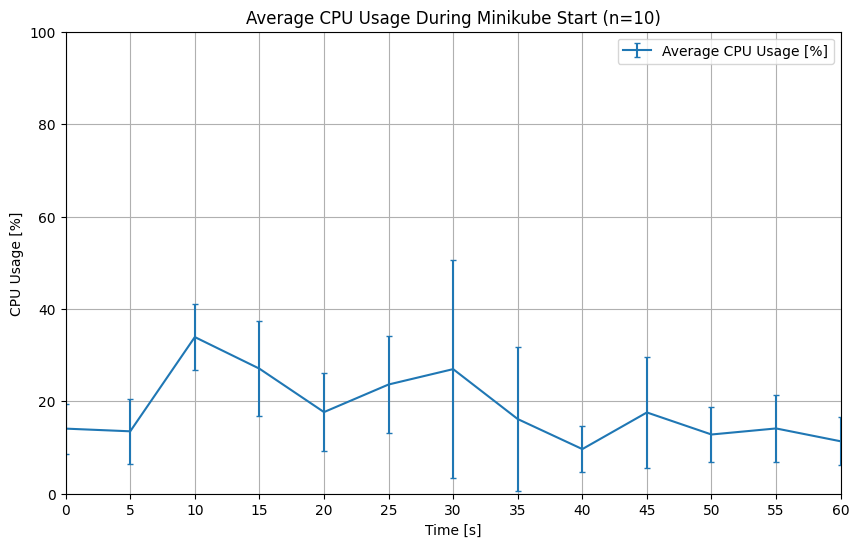

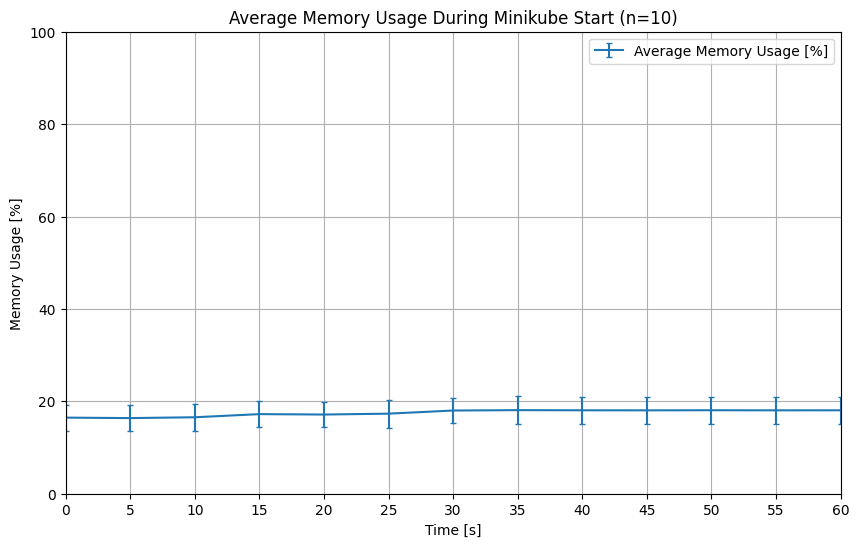

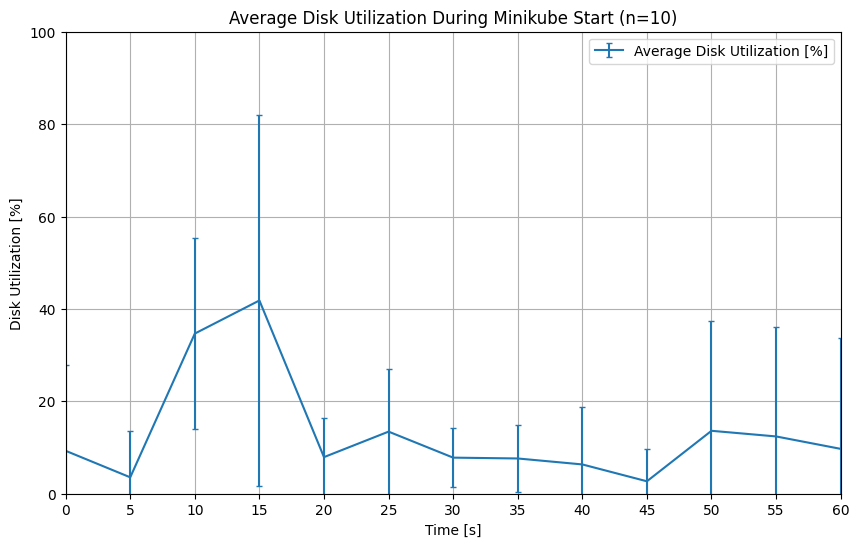

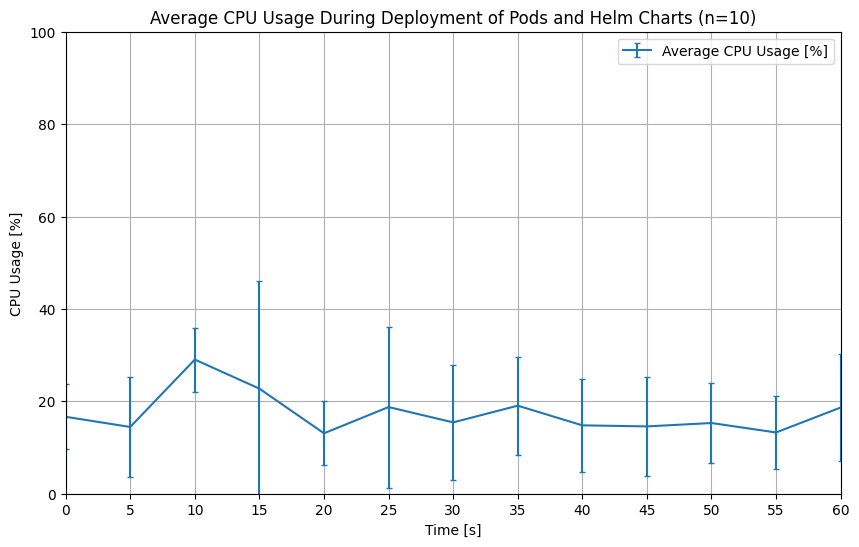

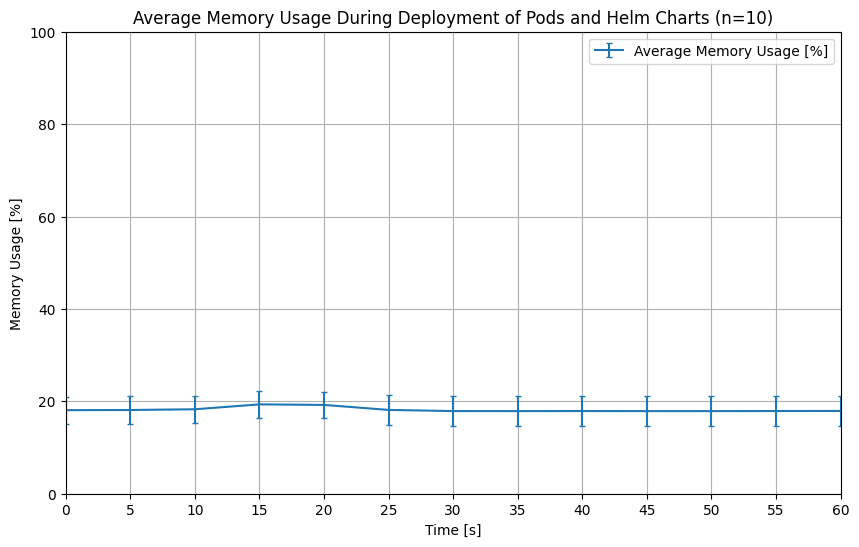

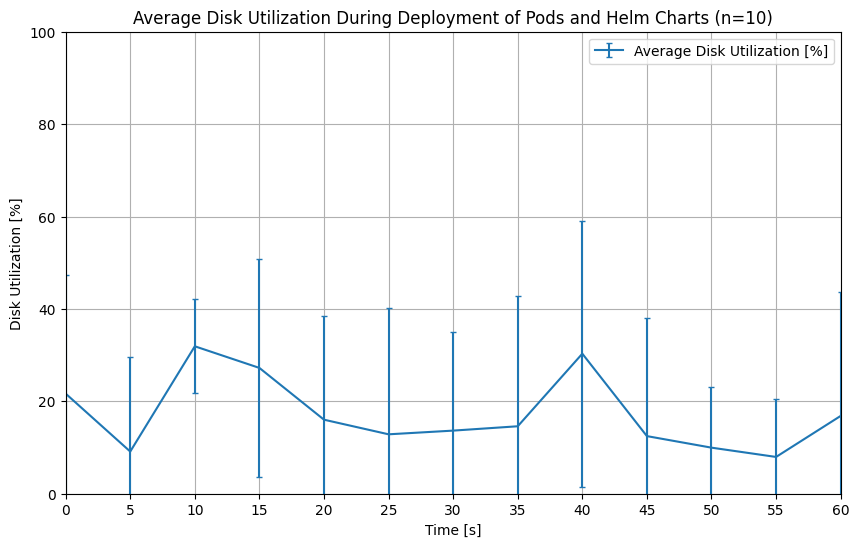

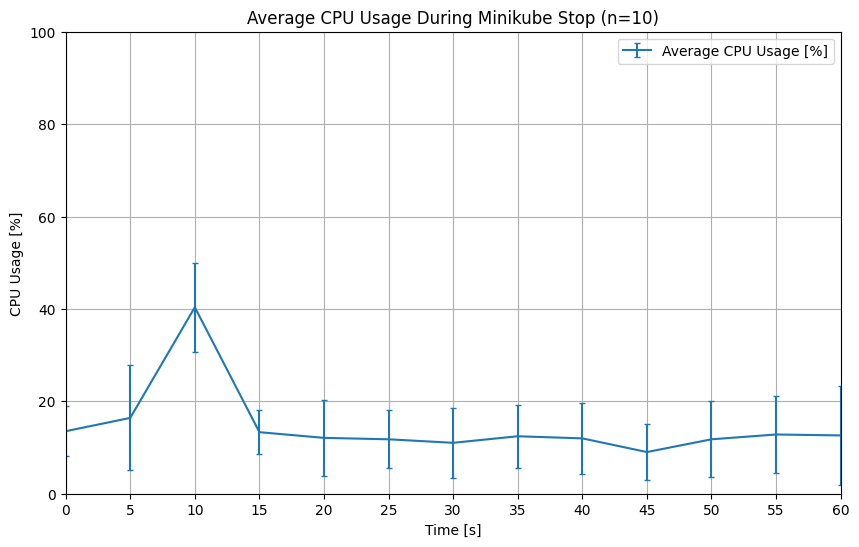

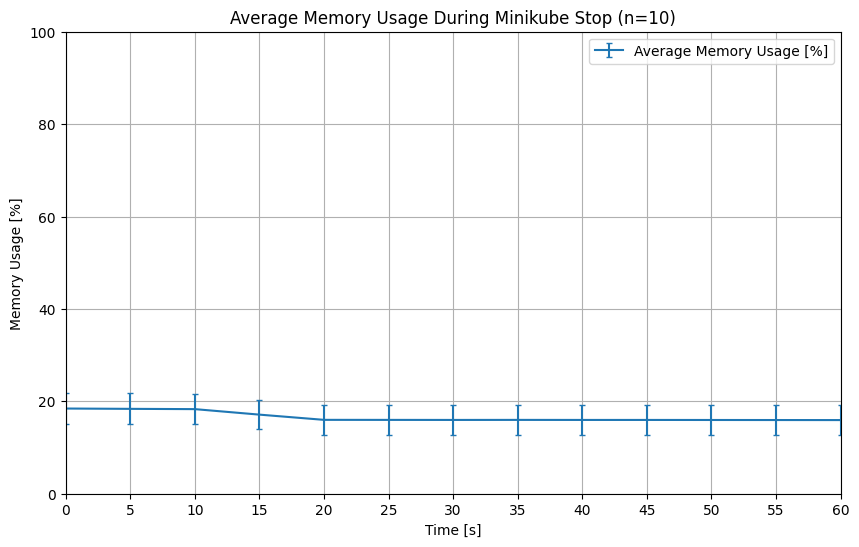

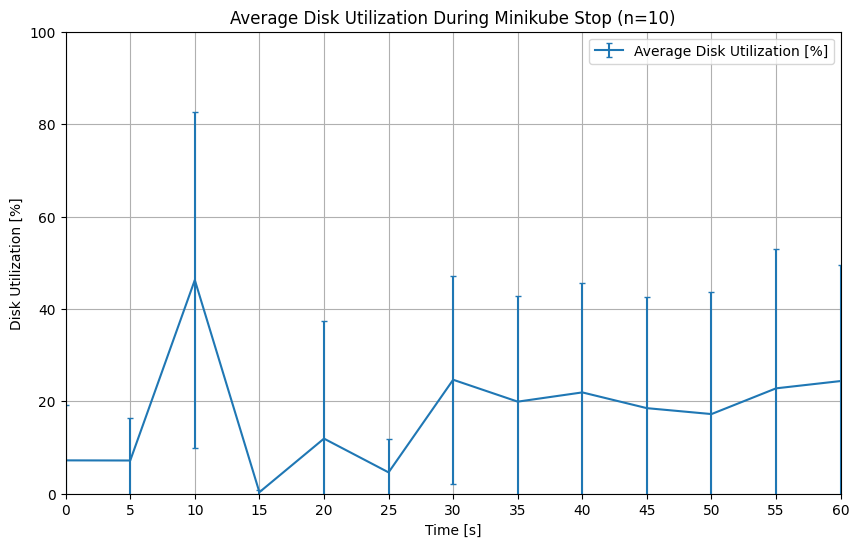

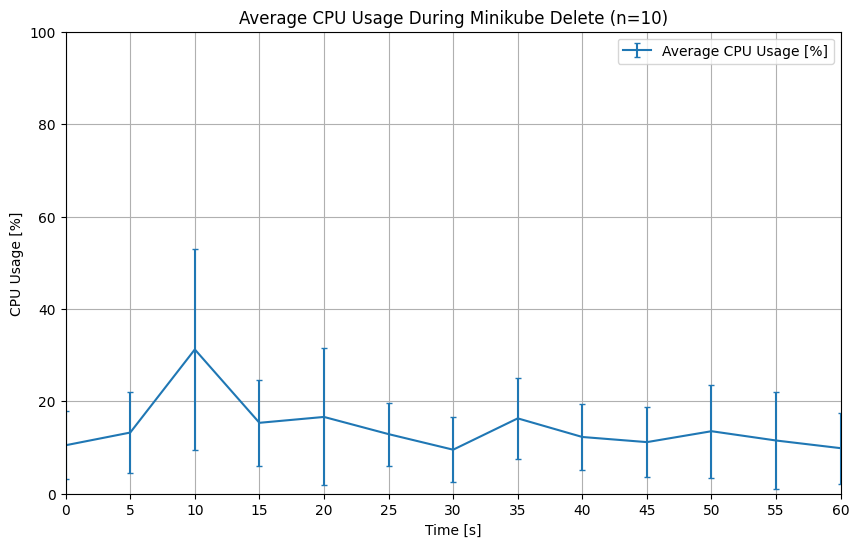

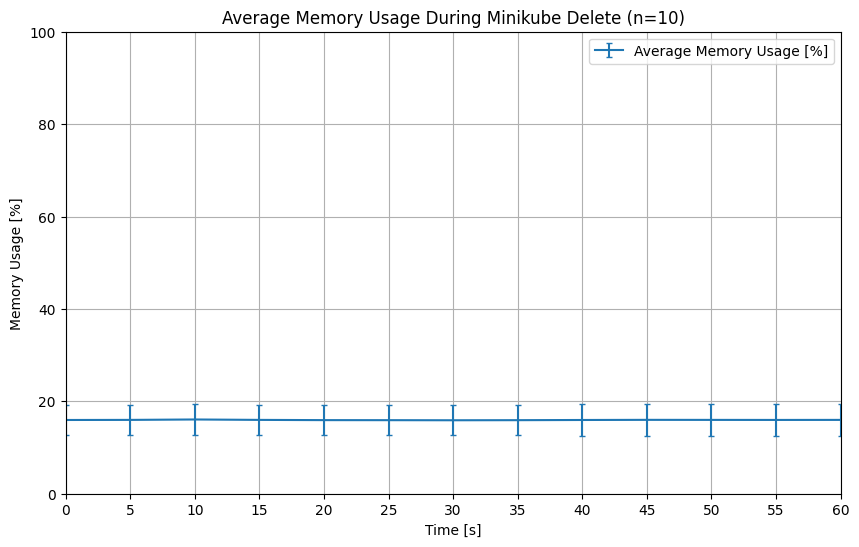

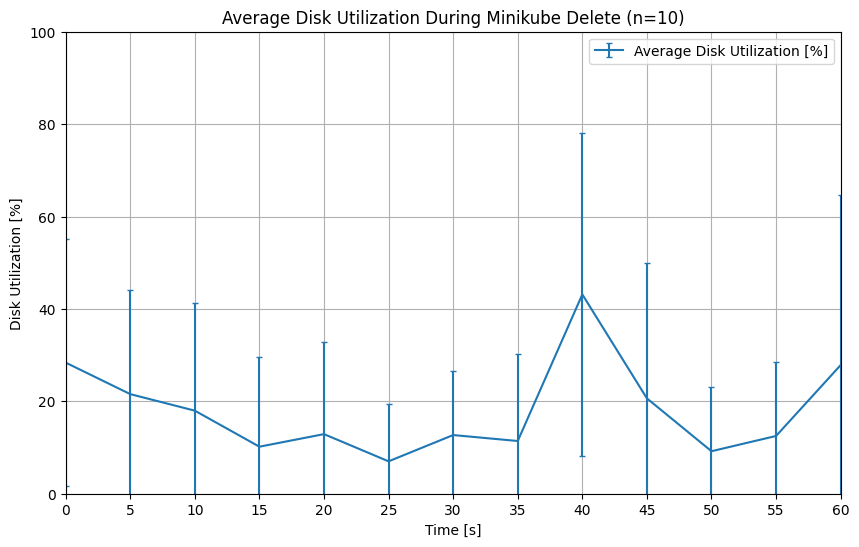

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Number of CSV files to process
NUM_FILES = 10

# Dictionary to store DataFrames for each phase
phases_data = {
    'start': [],
    'deployment': [],
    'end': [],
    'delete': []
}

# Read all CSV files
for i in range(1, NUM_FILES + 1):
    phases_data['start'].append(pd.read_csv(f"minikube_cpu_mem_disk/start_{i}.csv"))
    phases_data['deployment'].append(pd.read_csv(f"minikube_cpu_mem_disk/deployment_{i}.csv"))
    phases_data['end'].append(pd.read_csv(f"minikube_cpu_mem_disk/end_{i}.csv"))
    phases_data['delete'].append(pd.read_csv(f"minikube_cpu_mem_disk/delete_{i}.csv"))

# Calculate averages and standard deviations for each phase
avg_metrics = {}
std_metrics = {}
for phase, dfs in phases_data.items():
    # Initialize DataFrames
    avg_metrics[phase] = pd.DataFrame()
    std_metrics[phase] = pd.DataFrame()
    
    # Find minimum length across all files for this phase
    min_length = min(len(df) for df in dfs)
    
    # Trim all dataframes to minimum length
    dfs_trimmed = [df.iloc[:min_length] for df in dfs]
    
    # Use timestamp from first file
    avg_metrics[phase]['timestamp'] = dfs_trimmed[0]['timestamp'].str.replace('s', '').astype(float)
    
    # Calculate averages and std for each metric
    metrics = ['cpu_usage_percent', 'mem_usage_percent', 'disk_usage_percent']
    for metric in metrics:
        values = np.array([df[metric].values[:min_length] for df in dfs])
        avg_metrics[phase][metric] = np.mean(values, axis=0)
        std_metrics[phase][metric] = np.std(values, axis=0)
    
    # print('Metric:',metric)
    # print('Phase', phase)
    # print(std_metrics[phase][metric])

# Plot averaged results with error bars
phase_names = {
    'start': "Minikube Start",
    'deployment': "Deployment of Pods and Helm Charts",
    'end': "Minikube Stop",
    'delete': "Minikube Delete"
}

for phase, data in avg_metrics.items():
    # CPU Usage
    plt.figure(figsize=(10, 6))
    plt.errorbar(data['timestamp'], 
                data['cpu_usage_percent'],
                yerr=std_metrics[phase]['cpu_usage_percent'],
                label='Average CPU Usage [%]',
                capsize=2)
    plt.title(f"Average CPU Usage During {phase_names[phase]} (n={NUM_FILES})")
    plt.xlim(0, 60)
    plt.xticks(np.arange(0, 65, 5))
    plt.ylim(0, 100)
    plt.xlabel("Time [s]")
    plt.ylabel("CPU Usage [%]")
    plt.grid()
    plt.legend()
    plt.show()

    # Memory Usage
    plt.figure(figsize=(10, 6))
    plt.errorbar(data['timestamp'], 
                data['mem_usage_percent'],
                yerr=std_metrics[phase]['mem_usage_percent'],
                label='Average Memory Usage [%]',
                capsize=2)
    plt.title(f"Average Memory Usage During {phase_names[phase]} (n={NUM_FILES})")
    plt.xlim(0, 60)
    plt.xticks(np.arange(0, 65, 5))
    plt.ylim(0, 100)
    plt.xlabel("Time [s]")
    plt.ylabel("Memory Usage [%]")
    plt.grid()
    plt.legend()
    plt.show()

    # Disk Usage
    plt.figure(figsize=(10, 6))
    plt.errorbar(data['timestamp'], 
                data['disk_usage_percent'],
                yerr=std_metrics[phase]['disk_usage_percent'],
                label='Average Disk Utilization [%]',
                capsize=2)
    plt.title(f"Average Disk Utilization During {phase_names[phase]} (n={NUM_FILES})")
    plt.xlim(0, 60)
    plt.xticks(np.arange(0, 65, 5))
    plt.ylim(0, 100)
    plt.xlabel("Time [s]")
    plt.ylabel("Disk Utilization [%]")
    plt.grid()
    plt.legend()
    plt.show()

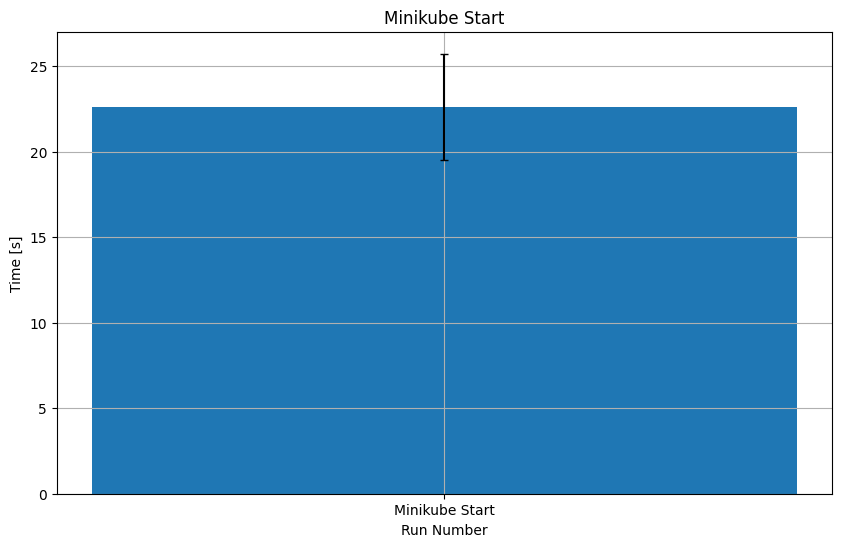

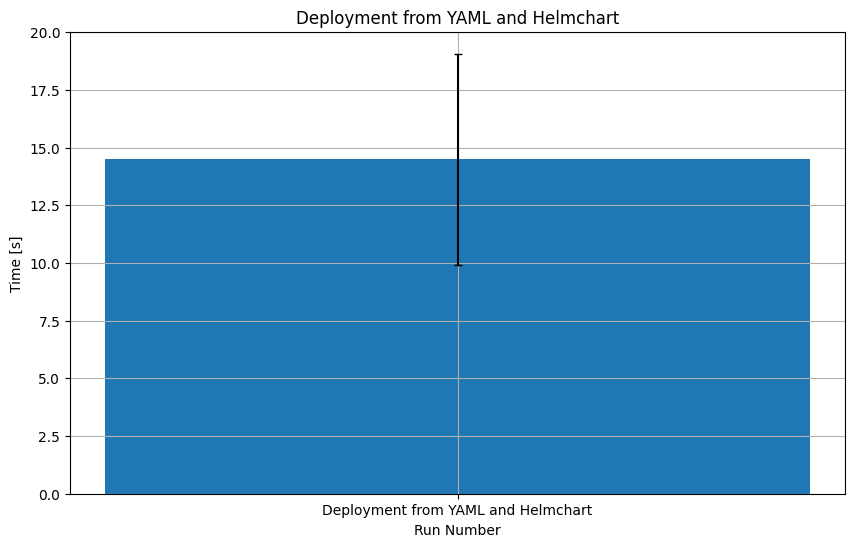

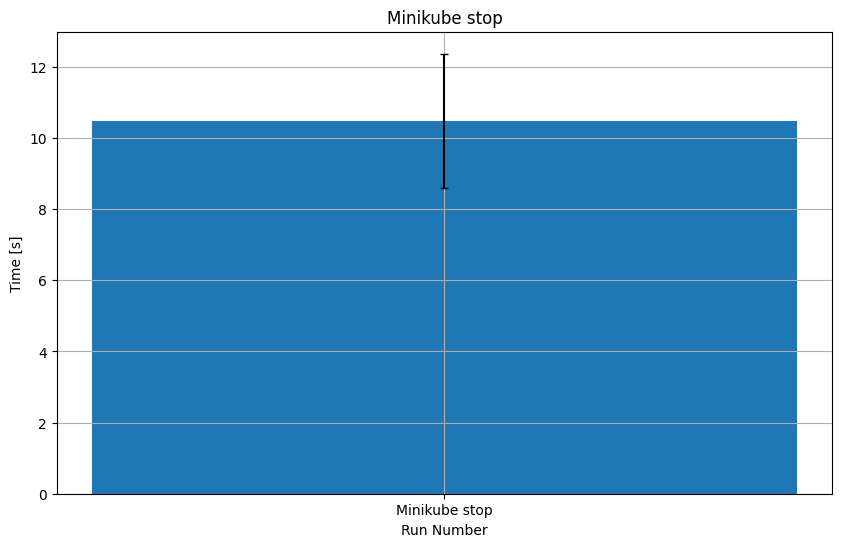

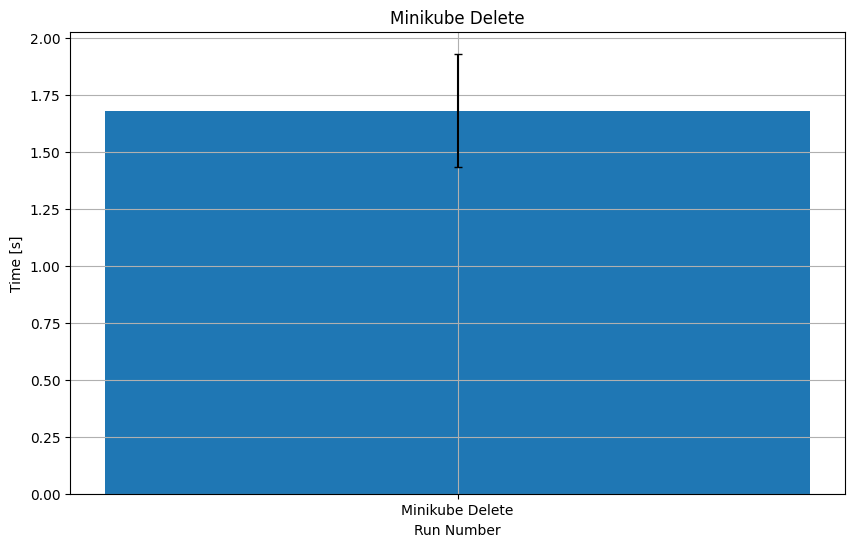

In [ ]:
# zmienić to jak będzie reszta tych danych 
import pandas as pd
import numpy as np
df = pd.read_csv("minikube_time.csv")

columns = {
    'start_time' : "Minikube Start",
    'deployment_time' : "Deployment from YAML and Helmchart",
    'stop_time' : "Minikube stop", 
    'delete_time' : "Minikube Delete"}
for metric, title in columns.items():
    stdev = np.std(df[metric])

    plt.figure(figsize=(10, 6))
    # x = [1,2,3,4,5,6,7,8,9,10]
    x = df[metric].mean()
    plt.bar(title, df[metric].mean(), yerr=stdev, capsize=3)
    # plt.errorbar(x, df[metric], yerr=stdev, capsize=3)
    plt.ylabel("Time [s]")
    plt.title(title)
    # plt.xticks(x)
    plt.grid()
    plt.show()